**Compare hydrogen demand**

This notebook compares hydrogen demand results from PyPSA-Eur with literature

Author: Alexander Meisinger

Project: H2Global meets Africa (FENES, OTH Regensburg)

In [247]:
# Import necessary Python libraries for data handling, plotting, and PyPSA network access
import os
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
import yaml
import itertools
import warnings
warnings.filterwarnings("ignore")

Define necessary functions

In [248]:
def h2_pypsa(config_path, pypsa_path, country):
    """
    Extract hydrogen demand from PyPSA network results based on configuration files.
    
    Parameters:
        config_path (str): Path to the directory containing YAML configuration files.
        pypsa_path (str): Path to the directory with PyPSA network results.
        country (str): "EU" for total demand or a specific country code (e.g., "DE").
    
    Returns:
        pd.DataFrame: Hydrogen demand in TWh indexed by year and scenario abbreviation.
    """
    h2_demand = pd.DataFrame()

    # Get all config files from the specified path
    ###files = ['config.gridfreeze.yaml', 'config.highH2demand.yaml', 'config.highcarbon.yaml', 'config.lowH2cost.yaml', 'config.main.yaml', 'config.lowcarbon-144h.yaml'] #'config.lowcarbon.yaml'
    files = ['config.gridfreeze.yaml', 'config.highH2demand.yaml', 'config.highcarbon.yaml', 'config.lowH2cost.yaml', 'config.main.yaml', 'config.lowcarbon.yaml']
    #files = ['config.lowcarbon-144h.yaml'] #'config.lowcarbon.yaml'

    for config_file in files:
        # Load the YAML configuration file
        with open(f"{config_path}/{config_file}") as file:
            config = yaml.safe_load(file)
        
        run_name = config["run"]["name"]
        clusters = config["scenario"]["clusters"][0]
        sectors_opts = config["scenario"]["sector_opts"][0]
        planing_horizon = config["scenario"]["planning_horizons"]


        for year in planing_horizon:
            # Load the PyPSA network for the specific scenario and year
            n = pypsa.Network(f"{pypsa_path}/{run_name}/networks/base_s_{clusters}__{sectors_opts}_{year}.nc")
            
            # Extract energy balance for hydrogen storage depending on the country scope
            if country == "EU":
                df_h2 = n.statistics.energy_balance()
                idx = pd.IndexSlice
                df_h2 = df_h2.loc[idx[:,:,"Hydrogen Storage"]].div(1e6)
            else:
                df_h2 = n.statistics.energy_balance(groupby=["carrier", "bus_carrier", "country"])
                idx = pd.IndexSlice
                df_h2 = df_h2.loc[idx[:,:,"Hydrogen Storage",country]].div(1e6)
            
            # Summarize negative hydrogen storage flows (indicating demand)
            new_data = pd.DataFrame([{ 
                "Year of H2 demand": int(year),
                "Value": abs(df_h2[df_h2 < 0].sum()),  
                "Abbreviation": run_name.split("-2025-2050-5-T-H-B-I-A")[0]
            }])

            h2_demand = pd.concat([h2_demand, new_data], ignore_index=True)

    # Reformat the dataframe to wide format with scenarios as columns
    h2_demand = h2_demand.pivot(index="Year of H2 demand", columns="Abbreviation", values="Value")
    h2_demand.index.name = None
    h2_demand.columns.name = None

    return h2_demand

Parameter settings (general)

In [249]:
# CSV file with h2 demand from literature
H2_Demand = os.path.join("literature_h2-demand.csv")
H2_Demand = pd.read_csv(H2_Demand, sep=";", decimal=",")

# Path settings for config and results from PyPSA-Eur
config_path = "/home/alex-charly/AP3/analyse-h2g-a-ap3-eu/config/H2Global-meets-Africa"
pypsa_path = "/home/alex-charly/AP3/pypsa-eur/results/myopic/"

H2 demand data Germany (literature): Preparation

In [250]:
# Filter dataset to include only entries for Germany
H2_Demand_Germany = H2_Demand.loc[H2_Demand['Location'] == 'Germany']

# Extract and sort unique years of hydrogen demand
Year = H2_Demand_Germany["Year of H2 demand"].drop_duplicates()
Year.sort_values(ascending=True, inplace=True)

# Extract and sort unique scenario abbreviations
Abbreviation = H2_Demand_Germany["Abbreviation"].drop_duplicates()
Abbreviation.sort_values(ascending=True, inplace=True)

# Create an empty DataFrame to hold values for plotting
# Rows = years, Columns = scenario abbreviations
H2_Demand_Germany_Plot = pd.DataFrame(index=list(Year), columns=list(Abbreviation))

# Populate the plotting DataFrame with values
# Outer loop: iterate over each year
for a, b in H2_Demand_Germany_Plot.iterrows():  
      # Inner loop: iterate over each abbreviation    
      for c, d in H2_Demand_Germany_Plot.items():
            # Check if the current (year, abbreviation) combination exists in the data
            if H2_Demand_Germany[(H2_Demand_Germany["Year of H2 demand"] == a) & (H2_Demand_Germany["Abbreviation"] == c)].empty == False:
                  # Retrieve the value for that combination
                  H2_Demand_Germany_Help = H2_Demand_Germany[(H2_Demand_Germany["Year of H2 demand"] == a) & (H2_Demand_Germany["Abbreviation"] == c)]["Value"].reset_index() 
                  # Assign the value to the appropriate cell in the plot DataFrame
                  H2_Demand_Germany_Plot.loc[a][c] = H2_Demand_Germany_Help.loc[0, "Value"]

H2 demand data Germany (literature): Plotting

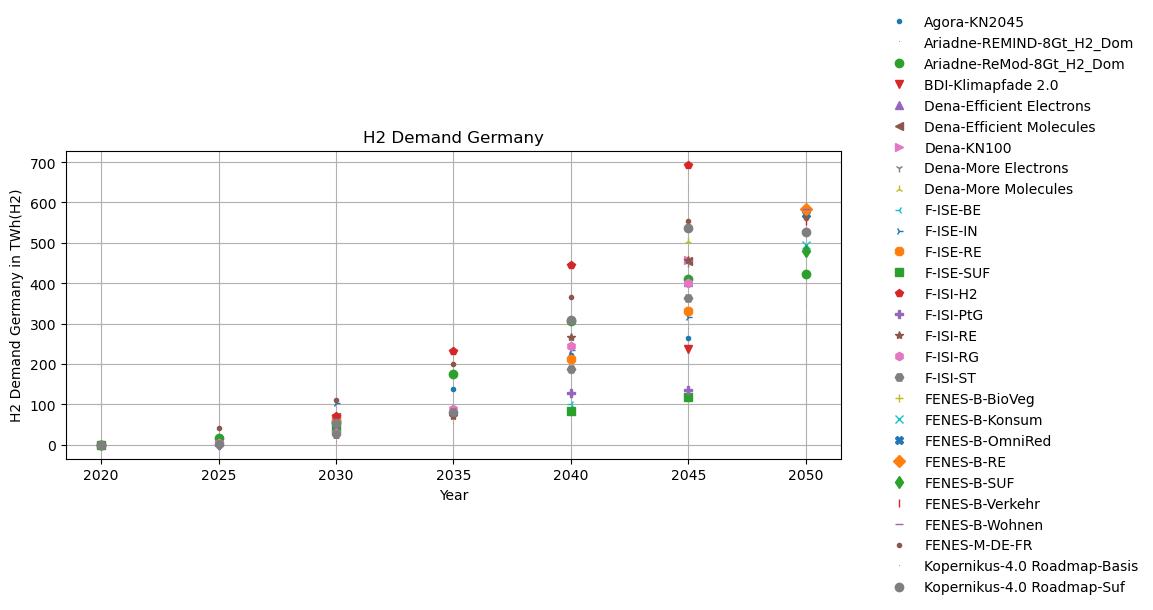

In [251]:
# Define a list of marker styles for plotting each scenario line
# This helps differentiate the lines in the plot visually
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",".",",","o"]

# Plot the hydrogen demand for Germany by scenario over time
# Each column (scenario) gets a unique marker from the 'markers' list
H2_Demand_Germany_Plot.plot(style=markers, figsize=(10,4))

# Optional: Uncomment below lines to use custom colors via seaborn
# NUM_COLORS = len(H2_Demand_Germany_Plot.columns)
# colors = sns.color_palette("husl", n_colors=NUM_COLORS)
# H2_Demand_Germany_Plot.plot(style=".", color=colors, figsize=(10,4))

# Customize the plot layout and labels
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Germany in TWh(H2)")
plt.title("H2 Demand Germany")

# Display the plot
plt.show()

Parameter settings (Germany)

In [252]:
country = "DE"

H2 demand data Germany (literature and PyPSA-Eur): Preparation

In [253]:
# Call the h2_pypsa function to extract hydrogen demand data for the specified country ("DE" = Germany)
# This returns a DataFrame with years as index and scenario abbreviations as columns
h2_demand_pypsa = h2_pypsa(config_path, pypsa_path, country)

# Merge the existing plot-ready hydrogen demand data for Germany with the newly extracted PyPSA demand data
# The merge is done on the year index (left join to retain all years from the existing plot data)
H2_Demand_Germany_all = H2_Demand_Germany_Plot.merge(h2_demand_pypsa, left_index=True, right_index=True, how="left")

INFO:pypsa.io:Imported network base_s_39__3H_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2035.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2050.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2025.nc has buses, carriers, generators, global_constraints, 

H2 demand data Germany (literature and PyPSA-Eur): Plotting

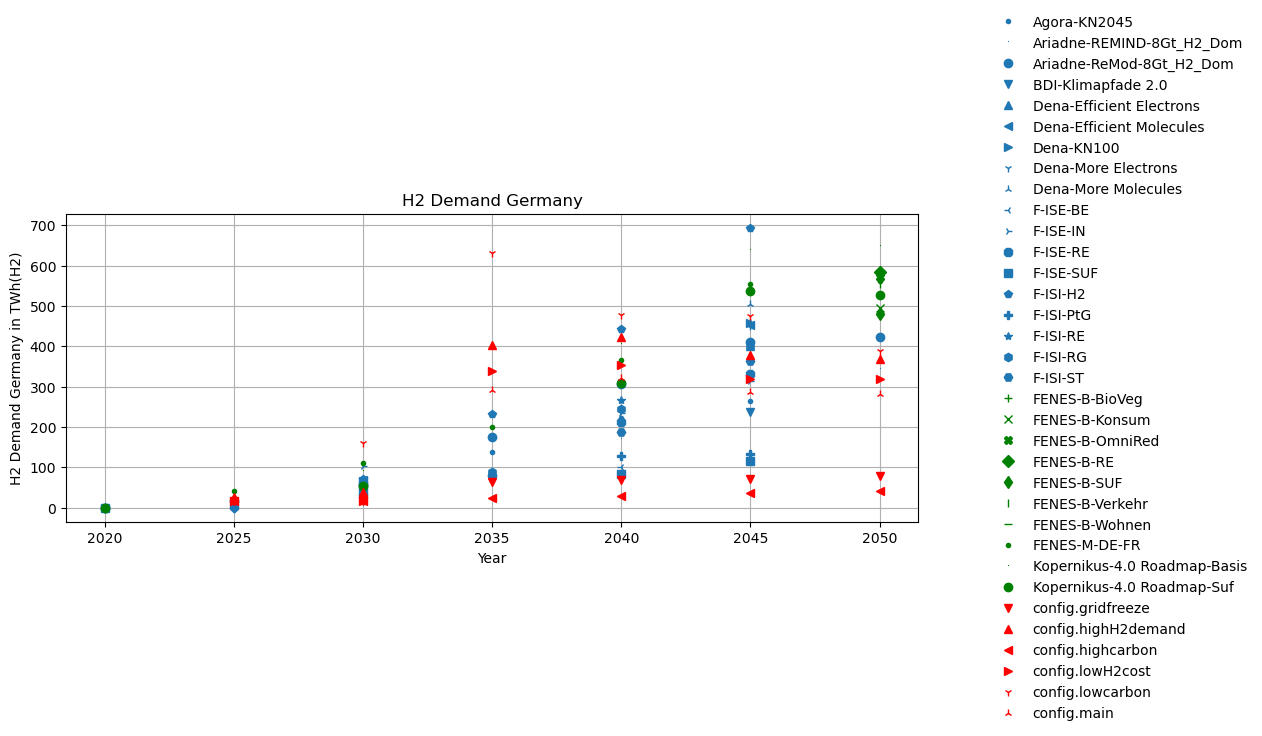

In [254]:
# Define marker and color combinations
unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Germany_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

for (col, (color, marker)) in zip(H2_Demand_Germany_all.columns, styles):
    if "config." in col:  # Corrected substring check
        H2_Demand_Germany_all[col].plot(ax=ax, linestyle="None", marker=marker, color="red", markersize=6, label=col)
    elif "FENES" in col or "Kopernikus" in col:
        H2_Demand_Germany_all[col].plot(ax=ax, linestyle="None", marker=marker, color="green", markersize=6, label=col)
    else:
        H2_Demand_Germany_all[col].plot(ax=ax, linestyle="None", marker=marker, color=color, markersize=6, label=col)

# Customize the plot layout and labels
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Germany in TWh(H2)")
plt.title("H2 Demand Germany")

# Display the plot
plt.show()

H2 demand data Germany (literature and PyPSA-Eur): Plotting with range

In [ ]:
# Custom labels for scenarios
label_mapping = {
    "config.lowcarbon": "Low Carbon",
    "config.highcarbon": "High Carbon",
    "config.main": "Reference",
    "config.gridfreeze": "Grid Freeze",
    "config.highH2demand": "High H$_2$ Demand",
    "config.lowH2cost": "Low H$_2$ Cost",}

marker_mapping = {
    "config.main": "o",          # Reference
    "config.lowcarbon": "*",     # Low Carbon
    "config.highcarbon": "<",    # High Carbon
    "config.lowh2cost": ">",     # Low H2 Cost
    "config.gridfreeze": "v",    # Grid Freeze
    "config.highh2demand": "^",  # High H2 Demand
}

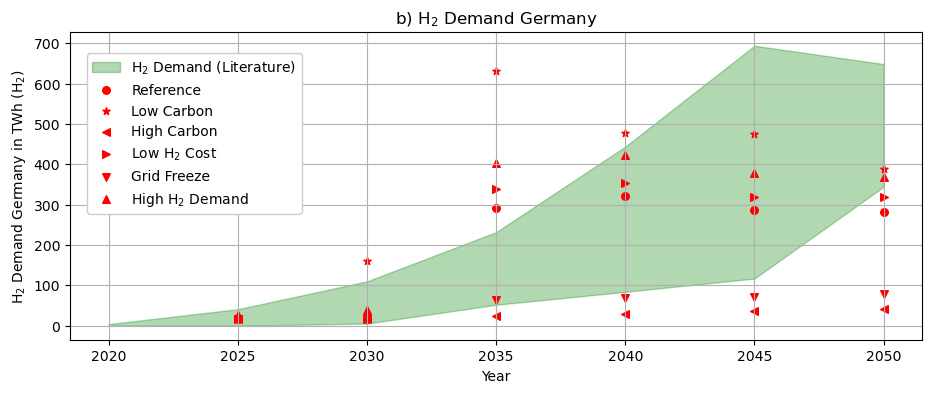

In [263]:
# Define marker and color combinations
H2_Demand_Germany_all = H2_Demand_Germany_all.apply(pd.to_numeric, errors='coerce')
H2_Demand_Germany_Plot = H2_Demand_Germany_Plot.apply(pd.to_numeric, errors='coerce')

unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Germany_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

lower_bound = H2_Demand_Germany_Plot.min(axis=1, skipna=True)
upper_bound = H2_Demand_Germany_Plot.max(axis=1, skipna=True)

ax.fill_between(H2_Demand_Germany_all.index, lower_bound, upper_bound, color='green', alpha=0.3, label="H$_2$ Demand (Literature)")

# Plot each scenario separately
for (col, (color, marker)) in zip(H2_Demand_Germany_all.columns, styles):
    if "config." in col.lower():  # Case-insensitive check for "myopic"
        # Default label
        label = col
        
        for key, value in label_mapping.items():
            if key.lower() in col.lower():
                label = value
        
        for key, value in marker_mapping.items():
            if key.lower() in col.lower():
                marker = value

        ax.scatter(H2_Demand_Germany_all.index, H2_Demand_Germany_all[col], color="red", marker=marker, s=30, label=label)

handles, labels = ax.get_legend_handles_labels()

order = [0, 6, 5, 3, 4, 1, 2]  # desired order by index

# Customize the plot layout and labels
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],loc='center right', bbox_to_anchor=(0.28, 0.67),frameon=True,framealpha=1,facecolor="white")
plt.xlabel("Year")
plt.grid()
plt.ylabel("H$_2$ Demand Germany in TWh (H$_2$)")
plt.title("b) H$_2$ Demand Germany")

# Display the plot
plt.show()

# CSV output
export_df = H2_Demand_Germany_all.copy()

export_df["lower_bound"] = lower_bound
export_df["upper_bound"] = upper_bound

export_df.to_csv("H2_Demand_Germany.csv")


H2 demand data Europe (literature): Preparation

In [257]:
# Filter dataset to include only entries for Europe
H2_Demand_Europe = H2_Demand.loc[H2_Demand['Location'] == 'Europe']

# Extract and sort unique years of hydrogen demand
Year = H2_Demand_Europe["Year of H2 demand"].drop_duplicates()
Year.sort_values(ascending=True, inplace=True)

# Extract and sort unique scenario abbreviations
Abbreviation = H2_Demand_Europe["Abbreviation"].drop_duplicates()
Abbreviation.sort_values(ascending=True, inplace=True)

# Create an empty DataFrame to hold values for plotting
# Rows = years, Columns = scenario abbreviations
H2_Demand_Europe_Plot = pd.DataFrame(index=list(Year), columns=list(Abbreviation))

# Populate the plotting DataFrame with values
# Outer loop: iterate over each year
for a, b in H2_Demand_Europe_Plot.iterrows():
      # Inner loop: iterate over each abbreviation     
      for c, d in H2_Demand_Europe_Plot.items():
            # Check if the current (year, abbreviation) combination exists in the data
            if H2_Demand_Europe[(H2_Demand_Europe["Year of H2 demand"] == a) & (H2_Demand_Europe["Abbreviation"] == c)].empty == False:
                  # Retrieve the value for that combinatio
                  H2_Demand_Europe_Help = H2_Demand_Europe[(H2_Demand_Europe["Year of H2 demand"] == a) & (H2_Demand_Europe["Abbreviation"] == c)]["Value"].reset_index() 
                  # Assign the value to the appropriate cell in the plot DataFrame
                  H2_Demand_Europe_Plot.loc[a][c] = H2_Demand_Europe_Help.loc[0, "Value"]

H2 demand data Europe (literature): Plotting

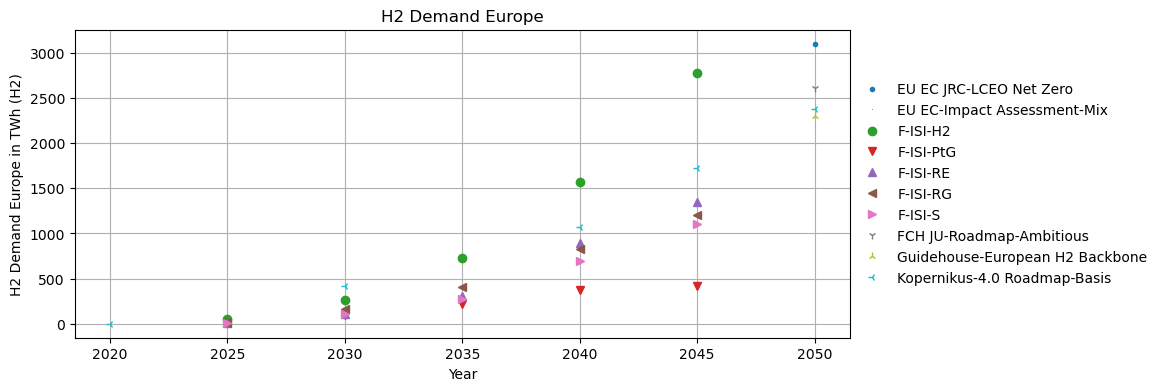

In [258]:
# Define a list of marker styles for plotting each scenario line
# This helps differentiate the lines in the plot visually
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",".",",","o"]

# Plot the hydrogen demand for Europe by scenario over time
# Each column (scenario) gets a unique marker from the 'markers' list
H2_Demand_Europe_Plot.plot(style=markers, figsize=(10,4))

# Optional: Uncomment below lines to use custom colors via seaborn
# H2_Demand_Europe_Plot.plot(style=".", figsize=(10,4))

# Customize the plot layout and labels
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Europe in TWh (H2)")
plt.title("H2 Demand Europe")

# Display the plot
plt.show()

Parameter settings (Europe)

In [259]:
country = "EU"

H2 demand data Europe (literature and PyPSA-Eur): Preparation

In [260]:
# Call the h2_pypsa function to extract hydrogen demand data for the specified country ("EU" = Europe)
# This returns a DataFrame with years as index and scenario abbreviations as columns
h2_demand_pypsa = h2_pypsa(config_path, pypsa_path, country)

# Merge the existing plot-ready hydrogen demand data for Germany with the newly extracted PyPSA demand data
# The merge is done on the year index (left join to retain all years from the existing plot data)
H2_Demand_Europe_all = H2_Demand_Europe_Plot.merge(h2_demand_pypsa, left_index=True, right_index=True, how="left")

INFO:pypsa.io:Imported network base_s_39__3H_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2035.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2050.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__3H_2025.nc has buses, carriers, generators, global_constraints, 

H2 demand data Europe (literature and PyPSA-Eur): Plotting

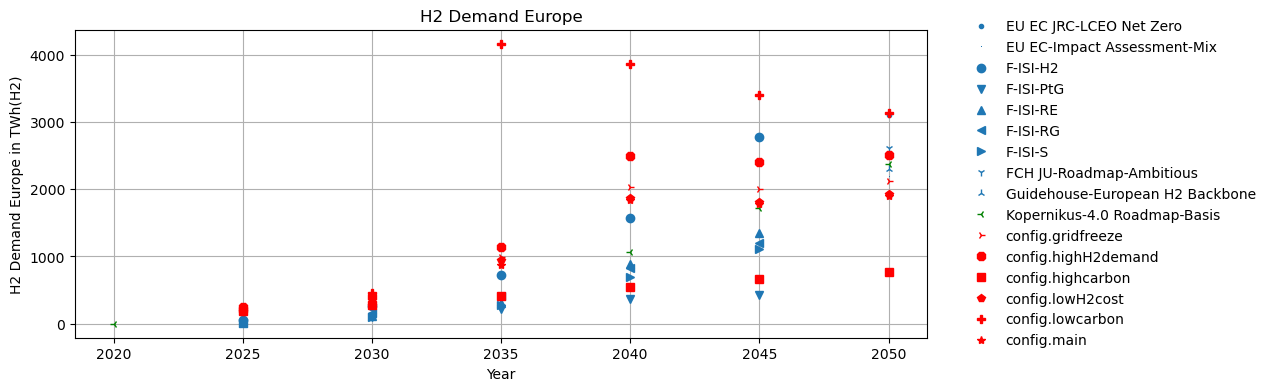

In [261]:
# Define marker and color combinations
unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Europe_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

for (col, (color, marker)) in zip(H2_Demand_Europe_all.columns, styles):
    if "config." in col:  # Corrected substring check
        H2_Demand_Europe_all[col].plot(ax=ax, linestyle="None", marker=marker, color="red", markersize=6, label=col)
    elif "FENES" in col or "Kopernikus" in col:
        H2_Demand_Europe_all[col].plot(ax=ax, linestyle="None", marker=marker, color="green", markersize=6, label=col)
    else:
        H2_Demand_Europe_all[col].plot(ax=ax, linestyle="None", marker=marker, color=color, markersize=6, label=col)

# Customize the plot layout and labels
plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Europe in TWh(H2)")
plt.title("H2 Demand Europe")

# Display the plot
plt.show()


H2 demand data Europe (literature and PyPSA-Eur): Plotting with range

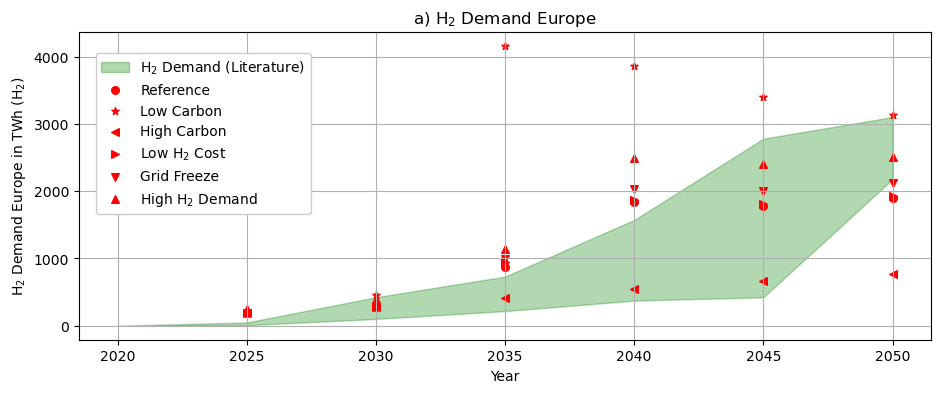

In [264]:
# Define marker and color combinations
H2_Demand_Europe_all = H2_Demand_Europe_all.apply(pd.to_numeric, errors='coerce')
H2_Demand_Europe_Plot = H2_Demand_Europe_Plot.apply(pd.to_numeric, errors='coerce')

unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Europe_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

lower_bound = H2_Demand_Europe_Plot.min(axis=1, skipna=True)
upper_bound = H2_Demand_Europe_Plot.max(axis=1, skipna=True)

ax.fill_between(H2_Demand_Europe_all.index, lower_bound, upper_bound, color='green', alpha=0.3, label="H$_2$ Demand (Literature)")

# Plot each scenario separately
for (col, (color, marker)) in zip(H2_Demand_Europe_all.columns, styles):
    if "config." in col.lower():  # Case-insensitive check for "myopic"
        # Default label
        label = col
        # Replace with custom label if match exists
        for key, value in label_mapping.items():
            if key.lower() in col.lower():
                label = value

        for key, value in marker_mapping.items():
            if key.lower() in col.lower():
                marker = value

        ax.scatter(H2_Demand_Europe_all.index, H2_Demand_Europe_all[col], color="red", marker=marker, s=30, label=label)


handles, labels = ax.get_legend_handles_labels()

order = [0, 6, 5, 3, 4, 1, 2]  # desired order by index

# Customize the plot layout and labels
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],loc='center right', bbox_to_anchor=(0.28, 0.67),frameon=True,framealpha=1,facecolor="white")
plt.xlabel("Year")
plt.grid()
plt.ylabel("H$_2$ Demand Europe in TWh (H$_2$)")
plt.title("a) H$_2$ Demand Europe")

# Display the plot
plt.show()

# CSV output
export_df = H2_Demand_Europe_all.copy()

export_df["lower_bound"] = lower_bound
export_df["upper_bound"] = upper_bound

export_df.to_csv("H2_Demand_Europe.csv")